# PCA - Principal Component Analysis for Breast Cancer 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [15]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)


In [6]:
X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,-1.373633e-16,1.00088,-2.029648,-0.689385,-0.215082,0.469393,3.971288
mean texture,569.0,6.868164e-17,1.00088,-2.229249,-0.725963,-0.104636,0.584176,4.651889
mean perimeter,569.0,-1.248757e-16,1.00088,-1.984504,-0.691956,-0.235980,0.499677,3.976130
mean area,569.0,-2.185325e-16,1.00088,-1.454443,-0.667195,-0.295187,0.363507,5.250529
mean smoothness,569.0,-8.366672e-16,1.00088,-3.112085,-0.710963,-0.034891,0.636199,4.770911
mean compactness,569.0,1.873136e-16,1.00088,-1.610136,-0.747086,-0.221940,0.493857,4.568425
mean concavity,569.0,4.995028e-17,1.00088,-1.114873,-0.743748,-0.342240,0.526062,4.243589
mean concave points,569.0,-4.995028e-17,1.00088,-1.261820,-0.737944,-0.397721,0.646935,3.927930
mean symmetry,569.0,1.748260e-16,1.00088,-2.744117,-0.703240,-0.071627,0.530779,4.484751
mean fractal dimension,569.0,4.745277e-16,1.00088,-1.819865,-0.722639,-0.178279,0.470983,4.910919


# PCA Model

In [8]:
pca_2d = PCA(n_components=2)

X_pca = pca_2d.fit_transform(X_scaled)

In [11]:
X_pca_df = pd.DataFrame(X_pca, columns=["PC 1", "PC 2"])

In [18]:
X_pca_df

,PC 1,PC 2,target,class_name
0,9.192837,1.948583,0,malignant
1,2.387802,-3.768172,0,malignant
2,5.733896,-1.075174,0,malignant
3,7.122953,10.275589,0,malignant
4,3.935302,-1.948072,0,malignant
...,...,...,...,...
564,6.439315,-3.576817,0,malignant
565,3.793382,-3.584048,0,malignant
566,1.256179,-1.902297,0,malignant
567,10.374794,1.672010,0,malignant


In [13]:
X_pca_df['target'] = y

In [17]:
X_pca_df['class_name'] = y.map({1: "benign", 0: "malignant"})

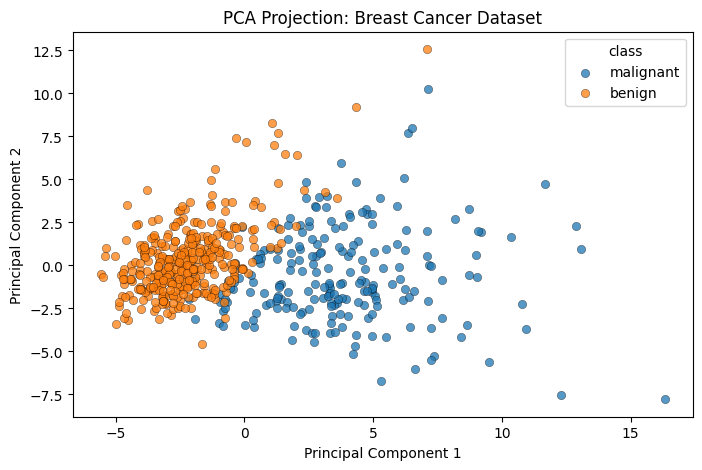

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

for target_value, class_name in enumerate(data.target_names):
    subset = X_pca_df[X_pca_df["target"] == target_value]
    
    ax.scatter(
        subset["PC 1"],
        subset["PC 2"],
        label=class_name,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.3
    )
    
ax.set_title("PCA Projection: Breast Cancer Dataset")

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

ax.legend(title="class")
 
plt.show()

# Explain Variance

In [22]:
explained = pd.Series(
    pca_2d.explained_variance_ratio_,
    index=["PC 1", "PC 2"],
    name="explained_variance_ratio"
)

In [23]:
print(explained.to_frame().round(3))
print("Разом перші 2 компоненти пояснють: ", explained.sum(), " варіативності.")

      explained_variance_ratio
PC 1                     0.443
PC 2                     0.190
Разом перші 2 компоненти пояснють:  0.6324320765155944  варіативності.


# Варіативність

In [27]:
pca_full = PCA()

pca_full.fit(X_scaled)

variance_df = pd.DataFrame({
    "component": range(1, len(pca_full.explained_variance_ratio_) + 1),
    "explained": pca_full.explained_variance_ratio_
})
variance_df['cumulative'] = variance_df['explained'].cumsum()

components_for_90 = variance_df.loc[variance_df['cumulative'] >= 0.90, "component"].iloc[0]

variance_df.head(20).round(3)



,component,explained,cumulative
0,1,0.443,0.443
1,2,0.190,0.632
2,3,0.094,0.726
3,4,0.066,0.792
4,5,0.055,0.847
5,6,0.040,0.888
6,7,0.023,0.910
7,8,0.016,0.926
8,9,0.014,0.940
9,10,0.012,0.952


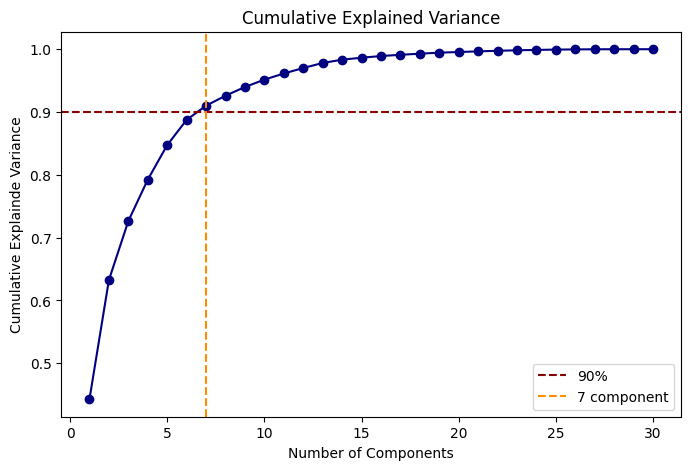

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    variance_df['component'],
    variance_df['cumulative'],
    marker="o",
    color="navy"
)

ax.axhline(0.90, color="darkred", linestyle="--", label="90%")
ax.axvline(components_for_90, color="darkorange", linestyle="--", label=f"{components_for_90} component")

ax.set_title("Cumulative Explained Variance")

ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explainde Variance")

ax.legend()

plt.show()

